# Aprendizaje Profundo con PyTorch

En el notebook anterior entrenamos modelos tradicionales de ML — Ridge, Lasso, RandomForest, GradientBoosting y XGBoost — y seleccionamos el modelo de mejor rendimiento mediante un flujo de trabajo de selección y ajuste. Aquí exploramos si una red neuronal puede mejorar esos resultados.

Las redes neuronales pueden capturar relaciones no lineales complejas sin ingeniería de características explícita. Sin embargo, para datos tabulares, a menudo tienen un rendimiento comparable a (o peor que) el gradient boosting bien ajustado. Este notebook sirve como introducción práctica a la construcción de modelos de regresión con PyTorch.

### Por qué se espera un rendimiento comparable
Si los resultados son cercanos, ese es en realidad el resultado esperado — no un fracaso de ninguno de los modelos.

**Los métodos de ensemble de árboles están diseñados específicamente para datos tabulares.** Modelos como GradientBoosting y XGBoost construyen conjuntos aditivos de árboles de decisión, cada uno corrigiendo los residuos de los anteriores. Los árboles de decisión manejan de forma nativa interacciones no lineales entre características (p. ej., "el grado importa más para casas grandes") sin ingeniería de características explícita. También son invariantes a la escala de las características, requieren un preprocesamiento mínimo y tienden a generalizar bien con conjuntos de datos de este tamaño (~15k muestras de entrenamiento).

**Las redes neuronales tienen una desventaja estructural en conjuntos de datos tabulares de tamaño pequeño a mediano.** Su poder proviene de aprender representaciones jerárquicas de grandes cantidades de datos — el régimen donde viven las imágenes, el texto y el audio. En un conjunto de datos tabular de ~15k muestras con ~20 características, un MLP de 3 capas no tiene ninguna ventaja estructural. Cada interacción que la red descubre, el ensemble de gradient boosting ya la ha capturado mediante divisiones. Además, la red debe superar la sobrecarga de la optimización basada en gradientes, la programación de la tasa de aprendizaje y el ajuste de la regularización.

**Nota importante:** En el notebook 05 ya incluimos XGBoost junto al `GradientBoostingRegressor` de sklearn. XGBoost está paralelizado, usa divisiones basadas en histogramas y tiene regularización incorporada — es más representativo de cómo se usa en práctica el gradient boosting. La comparación aquí es por tanto con el mejor resultado de ese conjunto completo de modelos.

**La conclusión práctica:** para datos tabulares de esta escala, siempre comienza con gradient boosting (preferiblemente XGBoost o LightGBM). Recurre a redes neuronales cuando tengas sustancialmente más datos, necesites aprendizaje de extremo a extremo (p. ej., incrustar texto o imágenes sin procesar junto a características tabulares), o cuando el problema tenga una estructura que los árboles no puedan capturar bien.

## Carga de Datos Preprocesados

In [ ]:
import numpy as npfrom pathlib import Pathdata_dir = Path("processed_data")X_train = np.load(data_dir / "X_train.npy")X_val = np.load(data_dir / "X_val.npy")X_test = np.load(data_dir / "X_test.npy")y_train = np.load(data_dir / "y_train.npy")y_val = np.load(data_dir / "y_val.npy")y_test = np.load(data_dir / "y_test.npy")feature_names = np.load(data_dir / "feature_names.npy", allow_pickle=True)n_features = X_train.shape[1]print(f"Training set:   {X_train.shape[0]:,} samples, {n_features} features")print(f"Validation set: {X_val.shape[0]:,} samples")print(f"Test set:       {X_test.shape[0]:,} samples")

Training set:   15,129 samples, 22 features
Validation set: 3,242 samples
Test set:       3,242 samples


## Escalado del Objetivo

A diferencia de los modelos basados en árboles, las redes neuronales son sensibles a la escala de la variable objetivo. Con precios de casas en bruto (~\$100k–\$2M), el error cuadrático MSE es del orden de $10^{11}$, causando inestabilidad de gradientes (actualizaciones grandes y erráticas), convergencia lenta y curvas de pérdida ruidosas.

Los modelos basados en árboles dividen en umbrales de características y nunca calculan gradientes, por lo que no se ven afectados por la escala del objetivo. Las redes neuronales, en cambio, se benefician enormemente de tener el objetivo en un rango normalizado.

Ajustamos un `StandardScaler` solo en `y_train` (para evitar fuga de datos), usamos los objetivos escalados durante el entrenamiento, e **invertimos la transformación de las predicciones de vuelta a valores en dólares** antes de calcular las métricas de evaluación.

In [ ]:
from sklearn.preprocessing import StandardScalery_scaler = StandardScaler()y_train_scaled = y_scaler.fit_transform(np.log1p(y_train).reshape(-1, 1))y_val_scaled   = y_scaler.transform(np.log1p(y_val).reshape(-1, 1))y_test_scaled  = y_scaler.transform(np.log1p(y_test).reshape(-1, 1))# fit_transform already returns forma (n, 1)print(f"y_train — mean: ${y_train.mean():,.0f}, std: ${y_train.std():,.0f}")print(f"y_train_scaled — mean: {y_train_scaled.mean():.4f}, std: {y_train_scaled.std():.4f}")

y_train — mean: $538,936, std: $369,699
y_train_scaled — mean: 0.0000, std: 1.0000


## Métricas de Evaluación

Reutilizamos la misma función de evaluación del notebook 05 para asegurar resultados comparables.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_scoredef evaluate_model(y_true: np.ndarray, y_pred: np.ndarray, set_name: str = "Set") -> dict:    rmse = np.sqrt(mean_squared_error(y_true, y_pred))    mae = mean_absolute_error(y_true, y_pred)    r2 = r2_score(y_true, y_pred)    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100    print(f"{set_name}:")    print(f"  RMSE: ${rmse:,.0f}")    print(f"  MAE:  ${mae:,.0f}")    print(f"  R²:   {r2:.4f}")    print(f"  MAPE: {mape:.2f}%")    return {"rmse": rmse, "mae": mae, "r2": r2, "mape": mape}

## Configuración de PyTorch

In [ ]:
import torchimport torch.nn as nnfrom torch.utils.data import TensorDataset, DataLoaderdevice = torch.device("cuda" if torch.cuda.is_available() else "cpu")print(f"Using device: {device}")

Using device: cpu


## Preparación de DataLoaders

PyTorch trabaja con tensores, no con arrays de numpy. Convertimos los datos y los envolvemos en objetos `DataLoader` para el entrenamiento por lotes.

Las características (X) ya están escaladas (del notebook 04b). Para el objetivo `y` usamos las versiones escaladas de la sección anterior (`y_train_scaled`, `y_val_scaled`, `y_test_scaled`).

In [ ]:
# Convert to float32 tensors (PyTorch default precision)X_train_t = torch.tensor(X_train, dtype=torch.float32)X_val_t = torch.tensor(X_val, dtype=torch.float32)X_test_t = torch.tensor(X_test, dtype=torch.float32)# No cambiar forma needed: already (n, 1) from the scalery_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)y_val_t   = torch.tensor(y_val_scaled,   dtype=torch.float32)y_test_t  = torch.tensor(y_test_scaled,  dtype=torch.float32)BATCH_SIZE = 256train_dataset = TensorDataset(X_train_t, y_train_t)val_dataset = TensorDataset(X_val_t, y_val_t)test_dataset = TensorDataset(X_test_t, y_test_t)# shuffle=True only for entrenamiento; validación and test order doesn't matter but we keep it deterministictrain_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)train_eval_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)  # for evaluación (no shuffle)val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)print(f"Training batches: {len(train_loader)}")print(f"Batch size: {BATCH_SIZE}")

Training batches: 60
Batch size: 256


## Definición del Modelo

Definimos una red completamente conectada (densa) simple. Para regresión tabular:
- Unas pocas capas ocultas con ancho decreciente es una arquitectura común
- **Batch normalization**: Ayuda a estabilizar y acelerar el entrenamiento
- **Dropout**: Proporciona regularización para prevenir el sobreajuste
- **Activaciones ReLU**: No linealidad estándar para las capas ocultas
- La capa de salida tiene una sola neurona (objetivo de regresión: precio) **sin activación** (queremos predicciones sin límites)

In [ ]:
class HousePriceNet(nn.Module):    def __init__(self, n_features: int, dropout_rate: float = 0.3):        super().__init__()        self.network = nn.Sequential(            nn.Linear(n_features, 256),            nn.BatchNorm1d(256),            nn.ReLU(),            nn.Dropout(dropout_rate),            nn.Linear(256, 128),            nn.BatchNorm1d(128),            nn.ReLU(),            nn.Dropout(dropout_rate * 0.5),  # Less dropout near the salida            nn.Linear(128, 64),            nn.BatchNorm1d(64),            nn.ReLU(),            nn.Linear(64, 1),        )    def forward(self, x: torch.Tensor) -> torch.Tensor:        return self.network(x)model = HousePriceNet(n_features).to(device)display(model)print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

HousePriceNet(
  (network): Sequential(
    (0): Linear(in_features=22, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.15, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Linear(in_features=64, out_features=1, bias=True)
  )
)


Total parameters: 48,001


## Configuración del Entrenamiento

Decisiones clave de entrenamiento:
- **Pérdida: MSE sobre el objetivo escalado**
Minimizamos el error cuadrático medio sobre el objetivo normalizado con StandardScaler. Después del StandardScaler, y tiene media = 0 y std = 1. El MSE es el promedio de errores cuadráticos en ese espacio escalado. Así:
   - MSE = 1.0 significa que el error cuadrático promedio iguala 1² = 1 unidad de varianza, es decir, el modelo no es mejor que predecir la media.
   - MSE = 0.0 sería un ajuste perfecto.
   - En la práctica, un modelo bien entrenado cae en algún punto de (0, 1), frecuentemente 0.1–0.5. En crudo, el MSE sería alrededor de $10^{11}$, produciendo gradientes enormes que desestabilizarían el entrenamiento.
- **Optimizador: Adam con decaimiento de peso**
Adam mantiene tasas de aprendizaje adaptativas por parámetro rastreando medias móviles de gradientes pasados, lo que resulta en una convergencia más rápida y estable que el SGD simple.
- **Detención temprana**
Rastreamos la mejor pérdida de validación observada hasta ahora (`best_val_loss`) y guardamos los pesos del modelo en ese punto (`best_state`):
   - Si la pérdida del epoch actual mejora → actualiza `best_val_loss`, sobreescribe `best_state`, reinicia contador a 0
   - De lo contrario → incrementa `epochs_without_improvement`
   - Cuando `epochs_without_improvement == PATIENCE` → detiene el entrenamiento y restaura `best_state`

Esto garantiza que devolvemos el modelo que generalizó *mejor* en el conjunto de validación — no el último epoch, que puede haberse sobreajustado ligeramente. También ahorra tiempo de cómputo: una vez que el modelo deja de mejorar, seguir entrenando es inútil.

In [ ]:
LEARNING_RATE = 1e-3EPOCHS = 300PATIENCE = 15  # Early stopping patiencecriterion = nn.MSELoss()optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Bucle de Entrenamiento

A diferencia del `.fit()` de sklearn, PyTorch requiere escribir el bucle de entrenamiento explícitamente. Esto implica más código, pero brinda total visibilidad sobre lo que ocurre.

Cada epoch tiene tres fases:
1. **Fase de entrenamiento** (`model.train()`): iterar sobre mini-lotes — pase hacia adelante, calcular pérdida MSE sobre los objetivos escalados, retropropagar gradientes, actualizar pesos con Adam.
2. **Fase de validación** (`model.eval()`): calcular pérdida MSE y recolectar todas las predicciones sin rastreo de gradientes. También invertir la transformación de predicciones de vuelta a dólares y calcular RMSE.
3. **Pase de entrenamiento adicional** (modo eval, sin gradientes): calcular RMSE de entrenamiento en dólares. Este pase adicional es necesario porque durante el entrenamiento el modelo estaba en modo `model.train()` (Dropout activo), lo que daría un RMSE artificialmente más alto y ruidoso.

El botón `model.train()` / `model.eval()` es crítico: controla el comportamiento de **Dropout** (activo solo durante el entrenamiento) y **BatchNorm** (usa estadísticas por lote durante el entrenamiento, media/varianza continua durante la evaluación). Por eso la pérdida de entrenamiento puede aparecer *más alta* que la de validación incluso cuando el modelo está aprendiendo bien — Dropout enmascara neuronas aleatoriamente durante el entrenamiento, haciendo cada pase hacia adelante más difícil.

In [ ]:
train_losses = []val_losses = []val_rmses = []best_val_loss = float("inf")best_epoch = 0epochs_without_improvement = 0for epoch in range(EPOCHS):    # --- entrenamiento phase ---    model.train()    running_loss = 0.0    n_batches = 0    for X_batch, y_batch in train_loader:        X_batch, y_batch = X_batch.to(device), y_batch.to(device)        optimizer.zero_grad()        predictions = model(X_batch)        loss = criterion(predictions, y_batch)        loss.backward()        optimizer.step()        running_loss += loss.item() * X_batch.size(0)        n_batches += 1    avg_train_loss = running_loss / len(train_loader.dataset)    train_losses.append(avg_train_loss)    # --- validación phase ---    model.eval()    running_val_loss = 0.0    n_val_batches = 0    all_val_preds = []    with torch.no_grad():        for X_batch, y_batch in val_loader:            X_batch, y_batch = X_batch.to(device), y_batch.to(device)            predictions = model(X_batch)            loss = criterion(predictions, y_batch)            running_val_loss += loss.item() * X_batch.size(0)            n_val_batches += 1            all_val_preds.append(predictions.cpu())  # collect for RMSE    avg_val_loss = running_val_loss / len(val_loader.dataset)    val_losses.append(avg_val_loss)    # validación RMSE in dollars (inverse-transform to original objetivo scale)    val_preds_scaled = torch.cat(all_val_preds).numpy()    val_preds_dollars = np.expm1(y_scaler.inverse_transform(val_preds_scaled).squeeze())    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds_dollars))    val_rmses.append(val_rmse)    # Early stopping check    if avg_val_loss < best_val_loss:        best_val_loss = avg_val_loss        best_epoch = epoch        epochs_without_improvement = 0        # Save best modelo weights        best_state = {k: v.clone() for k, v in model.state_dict().items()}    else:        epochs_without_improvement += 1    if (epoch + 1) % 25 == 0 or epoch == 0:        current_lr = optimizer.param_groups[0]["lr"]        print(            f"Epoch {epoch+1:3d}/{EPOCHS} | "            f"Train Loss: {avg_train_loss:.4f} | "            f"Val Loss: {avg_val_loss:.4f} | "            f"Val RMSE: ${val_rmse:,.0f} | "            f"LR: {current_lr:.1e}"        )    if epochs_without_improvement >= PATIENCE:        print(f"\nEarly stopping at epoch {epoch+1}. Best epoch: {best_epoch+1}")        break# Restore best weightsmodel.load_state_dict(best_state)print(f"\nRestored best model from epoch {best_epoch+1}")print(f"Best validation RMSE: ${val_rmses[best_epoch]:,.0f}")

Epoch   1/300 | Train Loss: 0.2997 | Val Loss: 0.2237 | Val RMSE: $188,530 | LR: 1.0e-03
Epoch  25/300 | Train Loss: 0.1172 | Val Loss: 0.1333 | Val RMSE: $130,880 | LR: 1.0e-03
Epoch  50/300 | Train Loss: 0.1026 | Val Loss: 0.1310 | Val RMSE: $126,851 | LR: 1.0e-03

Early stopping at epoch 61. Best epoch: 46

Restored best model from epoch 46
Best validation RMSE: $124,647


## Curvas de Aprendizaje

Usamos dos vistas complementarias para monitorear el entrenamiento:
1. **Pérdida MSE** — la señal que el optimizador minimiza realmente. Los valores son adimensionales (sobre el objetivo escalado), lo que los hace estables y comparables entre ejecuciones, pero difíciles de interpretar en términos de negocio.
2. **RMSE en dólares** — el mismo error expresado en las unidades del objetivo original ($). Esta curva responde a la pregunta práctica: *"En promedio, ¿cuánto se desvía la predicción del precio del modelo?"*

### Pérdida MSE: la vista de optimización

La pérdida MSE se calcula sobre el objetivo **escalado** (estandarizado a media ≈ 0, std ≈ 1). Un valor de 1.0 significa que el error cuadrático promedio iguala la varianza del objetivo — esencialmente tan malo como predecir la media. Un modelo bien entrenado debería alcanzar valores muy por debajo de 1.0.

**Nota sobre train > val pérdida:** Con Dropout y BatchNorm activos durante el entrenamiento, el MSE de entrenamiento es típicamente *más alto* que el MSE de validación — esto es esperado y no es señal de subajuste. Ambas capas están desactivadas durante la evaluación, haciendo el pase hacia adelante determinista y ligeramente más fácil.

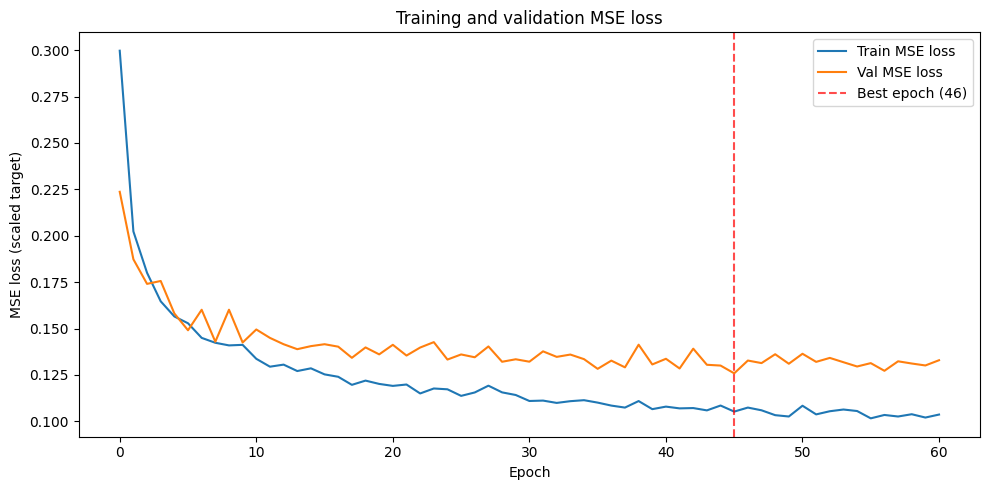

In [ ]:
import matplotlib.pyplot as pltfig, ax = plt.subplots(figsize=(10, 5))ax.plot(train_losses, label="Train MSE loss")ax.plot(val_losses, label="Val MSE loss")ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch + 1})")ax.set_xlabel("Epoch")ax.set_ylabel("MSE loss (scaled target)")ax.set_title("Training and validation MSE loss")ax.legend()plt.tight_layout()plt.show()

Qué buscar en este gráfico:
- **Ambas curvas descendiendo juntas**: El modelo está aprendiendo y generalizando.
- **Línea discontinua roja (mejor epoch)**: donde la detención temprana guardó los pesos — el punto antes de que comenzara el sobreajuste.
- **Pérdida de entrenamiento ≥ pérdida de validación**: normal con Dropout/BatchNorm como se explicó.
- **Pérdida de validación aplanándose luego aumentando ligeramente**: el optimizador comienza a ajustar el ruido del entrenamiento; la detención temprana lo previene.

### RMSE en dólares: la vista de interpretabilidad

Aquí rastreamos las mismas predicciones de validación, pero con el escalador invertido para que el error se exprese en dólares. Esta curva responde a la pregunta práctica: *"En promedio, ¿cuánto se aleja la predicción de precio del modelo?"*

La línea discontinua roja marca el mejor epoch — los pesos restaurados al final del entrenamiento. El RMSE en ese epoch es el número que comparamos con los modelos baseline.

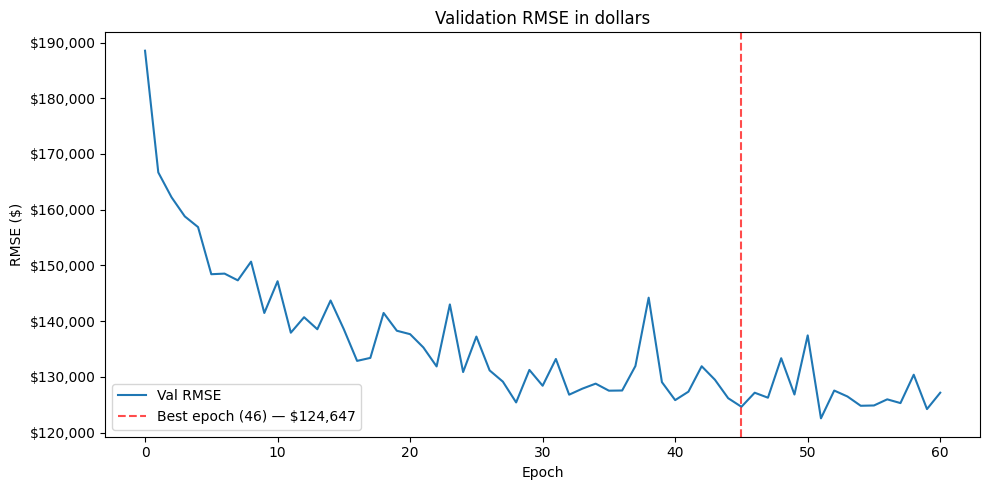

In [ ]:
import matplotlib.ticker as mtickerfig, ax = plt.subplots(figsize=(10, 5))ax.plot(val_rmses, label="Val RMSE")ax.axvline(x=best_epoch, color="red", linestyle="--", alpha=0.7, label=f"Best epoch ({best_epoch + 1}) — ${val_rmses[best_epoch]:,.0f}")ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))ax.set_xlabel("Epoch")ax.set_ylabel("RMSE ($)")ax.set_title("Validation RMSE in dollars")ax.legend()plt.tight_layout()plt.show()

La etiqueta en el marcador del mejor epoch muestra el RMSE de validación en dólares en ese punto. Compara esto con los modelos baseline en la sección de comparación — si la red neuronal es competitiva, el RMSE debería estar en el mismo rango que el gradient boosting (~\$136k del notebook 05).

Una curva de RMSE decreciente que se estabiliza es el patrón saludable: el modelo mejora rápidamente en los primeros epochs, luego las ganancias disminuyen a medida que se aproxima al mejor ajuste posible para esta arquitectura y conjunto de datos.

## Evaluación

Para generar predicciones, ejecutamos el modelo en modo evaluación (`model.eval()`) con el cómputo de gradientes desactivado (`torch.no_grad()`). Esto es más rápido y garantiza que BatchNorm/Dropout se comporten correctamente para la inferencia.

In [ ]:
@torch.no_grad()def predict(model: nn.Module, dataloader: DataLoader) -> np.ndarray:    """Run inference and inverse-transform predictions back to dollar values."""    model.eval()    predictions = []    for X_batch, _ in dataloader:        X_batch = X_batch.to(device)        preds = model(X_batch)        predictions.append(preds.cpu().numpy())    scaled_preds = np.concatenate(predictions).reshape(-1, 1)    return np.expm1(y_scaler.inverse_transform(scaled_preds).squeeze())

In [ ]:
train_pred = predict(model, train_eval_loader)val_pred = predict(model, val_loader)print("Neural Network Performance:")print("=" * 50)nn_train_metrics = evaluate_model(y_train, train_pred, "Training")print()nn_val_metrics = evaluate_model(y_val, val_pred, "Validation")

Neural Network Performance:
Training:
  RMSE: $101,988
  MAE:  $58,638
  R²:   0.9239
  MAPE: 11.23%

Validation:
  RMSE: $124,647
  MAE:  $70,014
  R²:   0.8691
  MAPE: 13.42%


## Comparación con Modelos de sklearn

Cargamos el mejor modelo tradicional guardado en el notebook 05 y lo evaluamos en el **conjunto de validación** para comparar ambos modelos en igualdad de condiciones — usando los mismos datos que ninguno de los modelos ha optimizado directamente. La selección del modelo (cuál va al conjunto de prueba) se hace aquí.

In [ ]:
import pandas as pdimport joblib# Load the best modelo selected in notebook 05 (whichever algoritmo won)sklearn_model = joblib.load(data_dir / "final_model.joblib")sklearn_model_name = type(sklearn_model).__name__sklearn_val_pred = sklearn_model.predict(X_val)sklearn_val_metrics = evaluate_model(y_val, sklearn_val_pred, f"{sklearn_model_name} (Validation)")

XGBRegressor (Validation):
  RMSE: $120,672
  MAE:  $69,890
  R²:   0.8774
  MAPE: 13.54%


In [ ]:
val_comparison = pd.DataFrame({    "Metric": ["RMSE ($)", "MAE ($)", "R²", "MAPE (%)"],    sklearn_model_name: [        f"${sklearn_val_metrics['rmse']:,.0f}",        f"${sklearn_val_metrics['mae']:,.0f}",        f"{sklearn_val_metrics['r2']:.4f}",        f"{sklearn_val_metrics['mape']:.2f}",    ],    "Neural Network": [        f"${nn_val_metrics['rmse']:,.0f}",        f"${nn_val_metrics['mae']:,.0f}",        f"{nn_val_metrics['r2']:.4f}",        f"{nn_val_metrics['mape']:.2f}",    ],}).set_index("Metric")print("Validation Set Comparison:")display(val_comparison)if sklearn_val_metrics["rmse"] <= nn_val_metrics["rmse"]:    selected_model_name = sklearn_model_nameelse:    selected_model_name = "Neural Network"print(f"\n-> Selected model for test evaluation: {selected_model_name} (lower validation RMSE)")

Validation Set Comparison:


,XGBRegressor,Neural Network
Metric,,
RMSE ($),"$120,672","$124,647"
MAE ($),"$69,890","$70,014"
R²,0.8774,0.8691
MAPE (%),13.54,13.42



-> Selected model for test evaluation: XGBRegressor (lower validation RMSE)


## Evaluación en el Conjunto de Prueba

El modelo fue seleccionado basándose en el **RMSE de validación** en la sección anterior. Ahora evaluamos ambos modelos en el conjunto de prueba para tener una imagen completa, pero esta comparación no influye en ninguna decisión — la selección ya fue fijada.

In [ ]:
test_pred = predict(model, test_loader)print("=" * 60)print("FINAL EVALUATION ON TEST SET")print("=" * 60)print("\nNeural Network:")nn_test_metrics = evaluate_model(y_test, test_pred, "Test")sklearn_test_pred = sklearn_model.predict(X_test)print(f"\n{sklearn_model_name}:")sklearn_test_metrics = evaluate_model(y_test, sklearn_test_pred, "Test")

FINAL EVALUATION ON TEST SET

Neural Network:
Test:
  RMSE: $132,963
  MAE:  $76,104
  R²:   0.8749
  MAPE: 13.11%

XGBRegressor:
Test:
  RMSE: $138,493
  MAE:  $79,639
  R²:   0.8643
  MAPE: 13.65%


In [ ]:
sklearn_label = f"{sklearn_model_name} {'<- selected' if selected_model_name != 'Neural Network' else ''}"nn_label = f"Neural Network {'<- selected' if selected_model_name == 'Neural Network' else ''}"test_comparison = pd.DataFrame({    "Metric": ["RMSE ($)", "MAE ($)", "R²", "MAPE (%)"],    sklearn_label.strip(): [        f"${sklearn_test_metrics['rmse']:,.0f}",        f"${sklearn_test_metrics['mae']:,.0f}",        f"{sklearn_test_metrics['r2']:.4f}",        f"{sklearn_test_metrics['mape']:.2f}",    ],    nn_label.strip(): [        f"${nn_test_metrics['rmse']:,.0f}",        f"${nn_test_metrics['mae']:,.0f}",        f"{nn_test_metrics['r2']:.4f}",        f"{nn_test_metrics['mape']:.2f}",    ],}).set_index("Metric")print("Test Set Comparison (model selected based on validation RMSE):")display(test_comparison)

Test Set Comparison (model selected based on validation RMSE):


,XGBRegressor <- selected,Neural Network
Metric,,
RMSE ($),"$138,493","$132,963"
MAE ($),"$79,639","$76,104"
R²,0.8643,0.8749
MAPE (%),13.65,13.11


### Una nota sobre la imparcialidad de esta comparación
El modelo de árbol fue ajustado con `GridSearchCV` sobre una cuadrícula de parámetros explícita. La red neuronal **no** fue sometida a una búsqueda automatizada equivalente — la arquitectura (3 capas ocultas, anchos 256/128/64, tasa de dropout 0.3, tasa de aprendizaje 1e-3) fue elegida manualmente. Esto constituye **ajuste implícito**: el autor ya codificó el conocimiento del dominio sobre lo que tiende a funcionar para la regresión tabular.

Una comparación estrictamente justa requeriría ya sea:
- Ejecutar una búsqueda de hiperparámetros sobre la arquitectura de la red y la configuración de entrenamiento (tasa de aprendizaje, dropout, número de capas, ancho, tamaño de lote, …), o
- Evaluar el modelo de árbol solo con sus parámetros predeterminados.

Esto importa para interpretar el resultado:
- Si la red neuronal iguala al modelo de árbol ajustado, lo hace porque la arquitectura elegida manualmente resultó ser adecuada — no porque las redes neuronales sean intrínsecamente competitivas a esta escala.
- Una red neuronal mal elegida (p. ej., con muy poca regularización, demasiadas capas para 15k muestras) rendiría notablemente peor. El modelo de árbol ajustado es más robusto a las elecciones arquitectónicas.

**La conclusión práctica sigue sin cambios**: para conjuntos de datos tabulares de esta escala, los modelos basados en árboles ganan no solo en precisión sino abrumadoramente en *tiempo del practicante*. Obtener una red neuronal competitiva requiere un ajuste arquitectónico cuidadoso; obtener un modelo XGBoost competitivo requiere una búsqueda en cuadrícula sobre un puñado de hiperparámetros interpretables.

### Interpretación de la comparación
**Divergencia RMSE vs. MAE**
El RMSE y el MAE miden lo mismo — el error de predicción en dólares — pero ponderan los errores de forma diferente. El RMSE eleva al cuadrado cada error antes de promediar, por lo que un solo error grande (p. ej., una casa de lujo predicha en \$800k que en realidad se vendió por \$1.4M) contribuye mucho más al RMSE que al MAE.

Cuando un modelo tiene un MAE más bajo pero un RMSE más alto que el otro, significa que ese modelo comete errores *típicos más pequeños* pero *errores de peor caso más grandes* en valores atípicos de alto valor. El modelo con el RMSE más bajo es mejor controlando esas predicciones catastróficas, incluso si su error promedio es ligeramente más alto.

**¿Qué métrica priorizar?**
- **RMSE** es apropiado cuando los errores grandes son desproporcionadamente costosos — p. ej., si el sistema se usa para valorar garantías hipotecarias, un error de \$400k en una propiedad de lujo es mucho más dañino que dos errores de \$200k en otro lugar.
- **MAE** (y MAPE) son más apropiados cuando los errores se tratan linealmente — p. ej., para una herramienta de valoración de uso general donde cada dólar de error tiene el mismo peso independientemente del precio de la propiedad.

Para este conjunto de datos, donde las propiedades de alto valor son una pequeña minoría, la diferencia de RMSE es impulsada por un puñado de predicciones atípicas. Ambos modelos son competitivos, y la brecha es poco probable que importe en la mayoría de las aplicaciones prácticas a precios típicos.

## Análisis de Predicciones

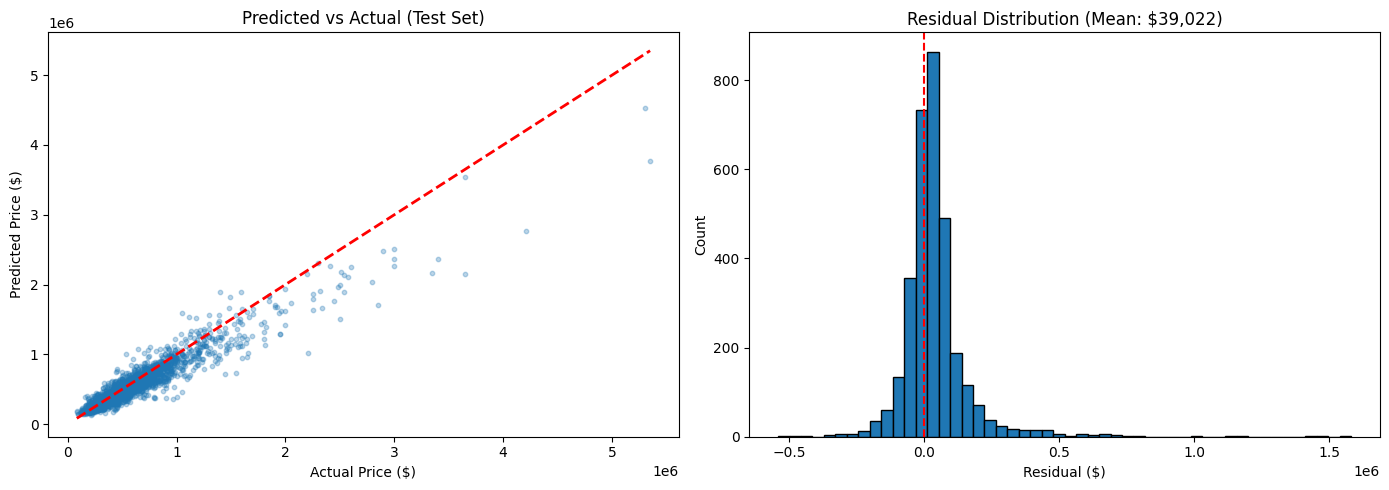

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))# Predicted vs Actualaxes[0].scatter(y_test, test_pred, alpha=0.3, s=10)axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)axes[0].set_xlabel("Actual Price ($)")axes[0].set_ylabel("Predicted Price ($)")axes[0].set_title("Predicted vs Actual (Test Set)")# Residualsresiduals = y_test - test_predaxes[1].hist(residuals, bins=50, edgecolor="black")axes[1].axvline(x=0, color="r", linestyle="--")axes[1].set_xlabel("Residual ($)")axes[1].set_ylabel("Count")axes[1].set_title(f"Residual Distribution (Mean: ${residuals.mean():,.0f})")plt.tight_layout()plt.show()

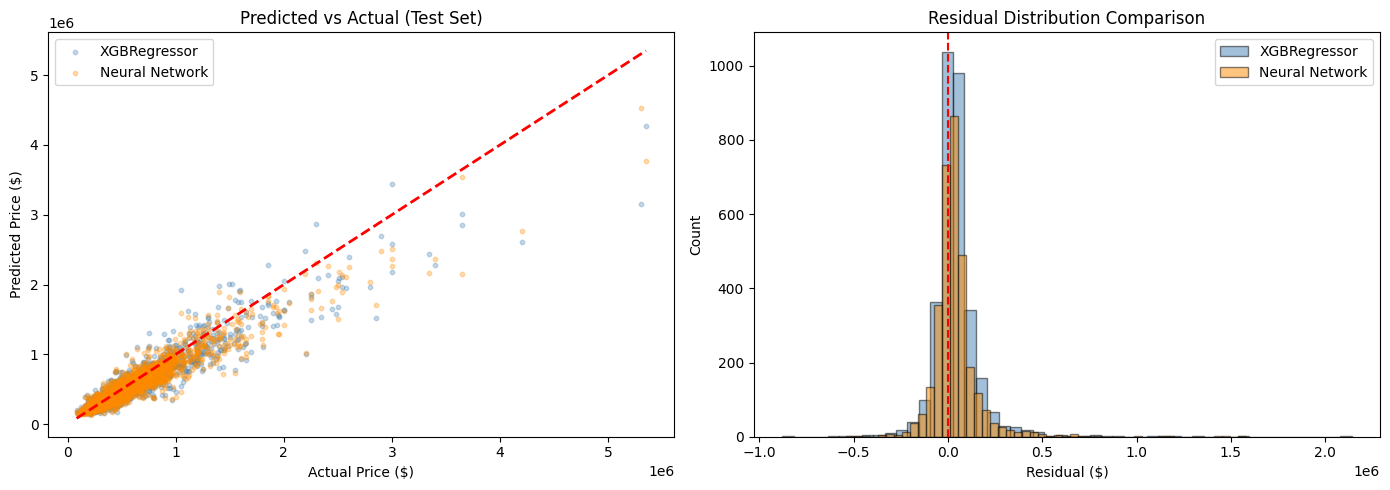

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))axes[0].scatter(y_test, sklearn_test_pred, alpha=0.3, s=10, label=sklearn_model_name, color="steelblue")axes[0].scatter(y_test, test_pred, alpha=0.3, s=10, label="Neural Network", color="darkorange")axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)axes[0].set_xlabel("Actual Price ($)")axes[0].set_ylabel("Predicted Price ($)")axes[0].set_title("Predicted vs Actual (Test Set)")axes[0].legend()sklearn_residuals = y_test - sklearn_test_prednn_residuals = y_test - test_predaxes[1].hist(sklearn_residuals, bins=50, alpha=0.5, label=sklearn_model_name, color="steelblue", edgecolor="black")axes[1].hist(nn_residuals, bins=50, alpha=0.5, label="Neural Network", color="darkorange", edgecolor="black")axes[1].axvline(x=0, color="r", linestyle="--")axes[1].set_xlabel("Residual ($)")axes[1].set_ylabel("Count")axes[1].set_title("Residual Distribution Comparison")axes[1].legend()plt.tight_layout()plt.show()